# Introduction - Exploratory Analysis

In this notebook, we will conduct an analysis of the data previously prepared in the path: `data/interim/hockey_teams.json`. This file, being partially processed, is easily accessible for import and ready for more detailed analytical examination.

This part of the workshop will focus on utilizing `pandas` and `matplotlib`, which were discussed during the course. The main objective is to familiarize ourselves with the dataset we are working on. Through a series of exercises:  
- we will get to know the structure of the data,  
- we will conduct elementary data exploration (EDA).

## Column Description

Below is a brief description of each column in our dataset:

- **Team Name**: The name of the team participating in the match.
- **Year**: The year in which the season takes place.
- **Wins**: The number of matches won by the team in the given season.
- **Losses**: The number of matches lost by the team in the given season.
- **OT Losses**: The number of matches lost by the team in overtime in the given season.
- **Win %**: The percentage of matches won by the team in the given season.
- **Goals For (GF)**: The number of goals scored by the team in the given season.
- **Goals Against (GA)**: The number of goals conceded by the team in the given season.
- **+ / -**: The difference between the number of goals scored and conceded by the team in the given season.

> Note: At this stage, certain significant simplifications were intentionally made in the analysis and they will not be explicitly mentioned, aiming for a discussion at the end of the workshop.

# Preparation

## Import libraries
Here, load the libraries that will be needed in the following steps

In [2]:
import json
import pandas as pd

json_path = r"C:\Users\rdpre\Workshop_-_files\data\interim\hockey_teams.json"
data_raw


# Loading the Dataset

We recommend loading the raw data into a variable with the suffix `_raw`. This will avoid the need to reload the data from the beginning in case of an error, which can be a time-consuming process.  
  
> **Tip:** A `json` file can be easily loaded using `pandas` with the `read_json` function - [click](https://pandas.pydata.org/docs/reference/api/pandas.read_json.html)  

Load data from the `hockey_teams` file here

In [12]:
df = df_raw.copy()

In [19]:
df.head(11)

,Team Name,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),+ / -
0,Boston Bruins,1990,44,24,,0.550,299,264,35
1,Buffalo Sabres,1990,31,30,,0.388,292,278,14
2,Calgary Flames,1990,46,26,,0.575,344,263,81
3,Chicago Blackhawks,1990,49,23,,0.613,284,211,73
4,Detroit Red Wings,1990,34,38,,0.425,273,298,-25
5,Edmonton Oilers,1990,37,37,,0.463,272,272,0
6,Hartford Whalers,1990,31,38,,0.388,238,276,-38
7,Los Angeles Kings,1990,46,24,,0.575,340,254,86
8,Minnesota North Stars,1990,27,39,,0.338,256,266,-10
9,Montreal Canadiens,1990,39,30,,0.487,273,249,24


In [6]:
import pandas as pd

# Cesta k souboru
json_path = r"C:\Users\rdpre\Workshop_-_files\data\interim\hockey_teams.json"

# Načtení dat do proměnné _raw
df_raw = pd.read_json(json_path)

# Rychlá kontrola
print(df_raw.head())  # vypíše prvních 5 řádků


            Team Name  Year  Wins  Losses OT Losses  Win %  Goals For (GF)  \
0       Boston Bruins  1990    44      24            0.550             299   
1      Buffalo Sabres  1990    31      30            0.388             292   
2      Calgary Flames  1990    46      26            0.575             344   
3  Chicago Blackhawks  1990    49      23            0.613             284   
4   Detroit Red Wings  1990    34      38            0.425             273   

   Goals Against (GA)  + / -  
0                 264     35  
1                 278     14  
2                 263     81  
3                 211     73  
4                 298    -25  


Check here if the data loaded correctly

In [7]:
print(len(df_raw))


582


In [8]:
print(df_raw["Team Name"].head())


0         Boston Bruins
1        Buffalo Sabres
2        Calgary Flames
3    Chicago Blackhawks
4     Detroit Red Wings
Name: Team Name, dtype: object


In [9]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 582 entries, 0 to 581
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Team Name           582 non-null    object 
 1   Year                582 non-null    int64  
 2   Wins                582 non-null    int64  
 3   Losses              582 non-null    int64  
 4   OT Losses           582 non-null    object 
 5   Win %               582 non-null    float64
 6   Goals For (GF)      582 non-null    int64  
 7   Goals Against (GA)  582 non-null    int64  
 8   + / -               582 non-null    int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 41.1+ KB


In [11]:
df_raw["Team Name"].value_counts()

Team Name
Boston Bruins              21
Buffalo Sabres             21
Calgary Flames             21
Chicago Blackhawks         21
Detroit Red Wings          21
Edmonton Oilers            21
Los Angeles Kings          21
New Jersey Devils          21
Montreal Canadiens         21
New York Rangers           21
New York Islanders         21
St. Louis Blues            21
Toronto Maple Leafs        21
Philadelphia Flyers        21
Pittsburgh Penguins        21
Vancouver Canucks          21
Washington Capitals        21
San Jose Sharks            20
Ottawa Senators            19
Tampa Bay Lightning        19
Florida Panthers           18
Dallas Stars               18
Colorado Avalanche         16
Phoenix Coyotes            15
Carolina Hurricanes        14
Nashville Predators        13
Mighty Ducks of Anaheim    12
Minnesota Wild             11
Columbus Blue Jackets      11
Atlanta Thrashers          11
Hartford Whalers            7
Winnipeg Jets               7
Anaheim Ducks               6


# Preliminary Data Transformation

## Standardizing Column Names

Currently, our dataset contains original column names which, from a technical standpoint, should not contain spaces or other special characters.

In this section, we will standardize and simplify the naming conventions to facilitate data processing in subsequent stages. We will apply the following column name mapping:

- **Team Name** -> `team`
- **Year** -> `season`
- **Wins** -> `victories`
- **Losses** -> `defeats`
- **OT Losses** -> `overtime_defeats`
- **Win %** -> `victory_percentage`
- **Goals For (GF)** -> `scored_goals`
- **Goals Against (GA)** -> `received_goals`
- **\+ / -** -> `goal_difference`

> At this point, we recommend creating a new DataFrame without the `_raw` postfix. For example, if the data was loaded into the variable `df_raw`, we now want to work with the variable `df`, where we will modify the column names.

In [21]:
# Vytvoření kopie původních dat
df = df_raw.copy()

# Mapování názvů sloupců
column_mapping = {
    "Team Name": "team",
    "Year": "season",
    "Wins": "victories",
    "Losses": "defeats",
    "OT Losses": "overtime_defeats",
    "Win %": "victory_percentage",
    "Goals For (GF)": "scored_goals",
    "Goals Against (GA)": "received_goals",
    "+ / -": "goal_difference"
}

# Přejmenování sloupců
df.rename(columns=column_mapping, inplace=True)

# Kontrola výsledku
print("✅ Nové názvy sloupců:")
print(df.columns.tolist())


✅ Nové názvy sloupců:
['team', 'season', 'victories', 'defeats', 'overtime_defeats', 'victory_percentage', 'scored_goals', 'received_goals', 'goal_difference']


## Removing Empty Values

As can be observed, the `overtime_defeats` column contains many empty values, and the expected data type is `int`. Before proceeding with further analysis, this column needs to be properly prepared.

To achieve this, we will perform the following steps:
- Check which symbol is used as an indicator of an empty field.
- Fill the empty fields with a value of 0.
- Then convert the data type of this column to `int`.

By following these steps, the `overtime_defeats` column will be ready for further analysis.

### Finding the Indicator of an Empty Field

In [22]:
print(df["overtime_defeats"].unique())


['' '3' '4' '6' '5' '0' '2' '1' '8' '7' '9' '12' '16' '11' '13' '14' '15'
 '10' '18']


### Overwriting Empty Values with 0

In [23]:
# 1. Nahraď prázdné řetězce nulou
df["overtime_defeats"] = df["overtime_defeats"].replace("", "0")

# 2. Převeď na celé číslo
df["overtime_defeats"] = df["overtime_defeats"].astype(int)

# 3. Ověř výsledek
print("✅ Typ dat:", df["overtime_defeats"].dtype)
print("🔢 Ukázka hodnot:", df["overtime_defeats"].unique())


✅ Typ dat: int64
🔢 Ukázka hodnot: [ 0  3  4  6  5  2  1  8  7  9 12 16 11 13 14 15 10 18]


In [24]:
print("Před úpravou:", df_raw["OT Losses"].unique())
print("Po úpravě:", df["overtime_defeats"].unique())


Před úpravou: ['' '3' '4' '6' '5' '0' '2' '1' '8' '7' '9' '12' '16' '11' '13' '14' '15'
 '10' '18']
Po úpravě: [ 0  3  4  6  5  2  1  8  7  9 12 16 11 13 14 15 10 18]


### Column Type Conversion

In [25]:
# Seznam sloupců
int_columns = ["victories", "defeats", "overtime_defeats", "scored_goals", "received_goals", "goal_difference"]
float_columns = ["victory_percentage"]

# Nahrazení prázdných hodnot
for col in int_columns + float_columns:
    df[col] = df[col].replace("", "0")

# Převod typů
for col in int_columns:
    df[col] = df[col].astype(int)

for col in float_columns:
    df[col] = df[col].astype(float)

# Kontrola
print("✅ Typy dat po převodu:")
print(df.dtypes[int_columns + float_columns])


✅ Typy dat po převodu:
victories               int64
defeats                 int64
overtime_defeats        int64
scored_goals            int64
received_goals          int64
goal_difference         int64
victory_percentage    float64
dtype: object


# Dataset Analysis

In this section, we will focus on answering fundamental questions about our dataset in the context of hockey games. The goal is to become familiar with the dataset and develop an intuition about it.  
  
Here is a list of exercises we will perform to find answers to key questions:  
  
- How many teams have participated in league games over the years?  
- What is the total number of available seasons?  
- What is the time span of the data?  
- Are there any suspicious or outlier values in the numerical columns?  
  
These exercises will help us better understand the structure and nature of our data.  

### Number of teams that participated in league matches

Here, indicate the total number of teams available in our dataset

In [27]:
unique_teams = df["team"].nunique()
print(f"✅ Počet unikátních týmů: {unique_teams}")

print(df["team"].unique())


✅ Počet unikátních týmů: 35
['Boston Bruins' 'Buffalo Sabres' 'Calgary Flames' 'Chicago Blackhawks'
 'Detroit Red Wings' 'Edmonton Oilers' 'Hartford Whalers'
 'Los Angeles Kings' 'Minnesota North Stars' 'Montreal Canadiens'
 'New Jersey Devils' 'New York Islanders' 'New York Rangers'
 'Philadelphia Flyers' 'Pittsburgh Penguins' 'Quebec Nordiques'
 'St. Louis Blues' 'Toronto Maple Leafs' 'Vancouver Canucks'
 'Washington Capitals' 'Winnipeg Jets' 'San Jose Sharks' 'Ottawa Senators'
 'Tampa Bay Lightning' 'Mighty Ducks of Anaheim' 'Dallas Stars'
 'Florida Panthers' 'Colorado Avalanche' 'Phoenix Coyotes'
 'Carolina Hurricanes' 'Nashville Predators' 'Atlanta Thrashers'
 'Columbus Blue Jackets' 'Minnesota Wild' 'Anaheim Ducks']


### Total number of seasons

Here, indicate the total number of seasons.

In [29]:
# Kolik a kdo sezón
print(df["team"].value_counts())

team
Boston Bruins              21
Buffalo Sabres             21
Calgary Flames             21
Chicago Blackhawks         21
Detroit Red Wings          21
Edmonton Oilers            21
Los Angeles Kings          21
New Jersey Devils          21
Montreal Canadiens         21
New York Rangers           21
New York Islanders         21
St. Louis Blues            21
Toronto Maple Leafs        21
Philadelphia Flyers        21
Pittsburgh Penguins        21
Vancouver Canucks          21
Washington Capitals        21
San Jose Sharks            20
Ottawa Senators            19
Tampa Bay Lightning        19
Florida Panthers           18
Dallas Stars               18
Colorado Avalanche         16
Phoenix Coyotes            15
Carolina Hurricanes        14
Nashville Predators        13
Mighty Ducks of Anaheim    12
Minnesota Wild             11
Columbus Blue Jackets      11
Atlanta Thrashers          11
Hartford Whalers            7
Winnipeg Jets               7
Anaheim Ducks               6
Quebe

### Time Span of Data

Here, we will examine the availability of data for individual seasons. The analysis will be conducted in two stages:  
- First, we will determine the time range of the data by identifying the start year (`start_year`) and the end year (`end_year`). This will allow us to establish for which seasons we have information.  
- Next, we will look for any gaps in the time data to ensure that we have a complete set of information for each season.   

At this point, we will determine the start year and end year of the data:

In [30]:
start_year = df["season"].min()
end_year = df["season"].max()

print(f"📅 Časový rozsah dat: {start_year} – {end_year}")


📅 Časový rozsah dat: 1990 – 2011


Here, we will check if data is present for each year within the determined range:

In [31]:
# Urči rozsah let
start_year = df["season"].min()
end_year = df["season"].max()

# Vytvoř seznam všech očekávaných sezón
expected_years = set(range(start_year, end_year + 1))

# Skutečné sezóny v datech
actual_years = set(df["season"].unique())

# Najdi chybějící roky
missing_years = sorted(expected_years - actual_years)

# Výstup
if missing_years:
    print(f"⚠️ Chybějící sezóny ({len(missing_years)}): {missing_years}")
else:
    print("✅ Máme kompletní sadu sezón bez mezer.")


⚠️ Chybějící sezóny (1): [2004]


### Analysis of Numerical Columns

Here we will examine the basic descriptive statistics for numerical columns.

To this end, describe and analyze the results for the following columns:

- victories
- defeats
- overtime_defeats
- victory_percentage
- scored_goals
- received_goals
- goal_difference

We are interested in the following statistics:
- mean,
- count,
- standard deviation,
- percentiles = `[0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1]`

In [33]:
percentiles = [0, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 1]

for col in columns_to_analyze:
    print(f"\n📈 Statistika pro sloupec: {col}")
    print("Počet hodnot:", df[col].count())
    print("Průměr:", round(df[col].mean(), 2))
    print("Směrodatná odchylka:", round(df[col].std(), 2))
    print("Percentily:")
    print(df[col].quantile(percentiles).round(2))


📈 Statistika pro sloupec: victories
Počet hodnot: 582
Průměr: 36.94
Směrodatná odchylka: 8.93
Percentily:
0.00     9.00
0.05    21.05
0.10    24.10
0.25    31.00
0.50    38.00
0.75    43.00
0.90    48.00
0.95    50.00
1.00    62.00
Name: victories, dtype: float64

📈 Statistika pro sloupec: defeats
Počet hodnot: 582
Průměr: 32.35
Směrodatná odchylka: 8.41
Percentily:
0.00    11.0
0.05    20.0
0.10    23.0
0.25    27.0
0.50    31.0
0.75    37.0
0.90    43.0
0.95    47.0
1.00    71.0
Name: defeats, dtype: float64

📈 Statistika pro sloupec: overtime_defeats
Počet hodnot: 582
Průměr: 4.59
Směrodatná odchylka: 4.61
Percentily:
0.00     0.0
0.05     0.0
0.10     0.0
0.25     0.0
0.50     4.0
0.75     8.0
0.90    11.0
0.95    13.0
1.00    18.0
Name: overtime_defeats, dtype: float64

📈 Statistika pro sloupec: victory_percentage
Počet hodnot: 582
Průměr: 0.46
Směrodatná odchylka: 0.1
Percentily:
0.00    0.12
0.05    0.28
0.10    0.32
0.25    0.39
0.50    0.46
0.75    0.53
0.90    0.58
0.95    0

# `team`

In this section, we will conduct a series of analyses on individual teams participating in the leagues. This will allow us to identify the teams that have performed best in the competitions over the years.


## Analysis of Team Participation in League Seasons
Let's perform the following exercises:

- Check how many teams have participated in all seasons of the selected league.
- Display the list of these teams.

In [38]:
# 1. Počet unikátních sezón
total_seasons = df["season"].nunique()

# 2. Počet sezón podle týmu
team_season_counts = df.groupby("team")["season"].nunique()

# 3. Týmy, které mají záznam pro každou sezónu
consistent_teams = team_season_counts[team_season_counts == total_seasons].index.tolist()

# 4. Výstup
print(f"✅ Počet týmů, které se účastnily všech {total_seasons} sezón: {len(consistent_teams)}")

for team in consistent_teams:
    print("-", team)


✅ Počet týmů, které se účastnily všech 21 sezón: 17
- Boston Bruins
- Buffalo Sabres
- Calgary Flames
- Chicago Blackhawks
- Detroit Red Wings
- Edmonton Oilers
- Los Angeles Kings
- Montreal Canadiens
- New Jersey Devils
- New York Islanders
- New York Rangers
- Philadelphia Flyers
- Pittsburgh Penguins
- St. Louis Blues
- Toronto Maple Leafs
- Vancouver Canucks
- Washington Capitals


List of teams that participated in all seasons of hockey competitions:

In [35]:
# Výpočet
total_seasons = df["season"].nunique()
team_season_counts = df.groupby("team")["season"].nunique()
consistent_teams = team_season_counts[team_season_counts == total_seasons].index.tolist()

# Výpis
for team in consistent_teams:
    print("-", team)


- Boston Bruins
- Buffalo Sabres
- Calgary Flames
- Chicago Blackhawks
- Detroit Red Wings
- Edmonton Oilers
- Los Angeles Kings
- Montreal Canadiens
- New Jersey Devils
- New York Islanders
- New York Rangers
- Philadelphia Flyers
- Pittsburgh Penguins
- St. Louis Blues
- Toronto Maple Leafs
- Vancouver Canucks
- Washington Capitals


The number of teams that have played in all seasons:

In [39]:
# 1. Zjisti celkový počet sezón v datech
total_seasons = df["season"].nunique()

# 2. Spočítej, kolik sezón má každý tým
team_season_counts = df.groupby("team")["season"].nunique()

# 3. Vyber týmy, které mají záznam pro každou sezónu
consistent_teams = team_season_counts[team_season_counts == total_seasons]

# 4. Výstup: počet těchto týmů
print(f"✅ Počet týmů, které hrály ve všech {total_seasons} sezónách: {len(consistent_teams)}")


✅ Počet týmů, které hrály ve všech 21 sezónách: 17


## Best Performing Teams in League History

Let's list the five best teams with the highest average `victory_percentage` over all years, presenting the data broken down by individual teams and seasons.

In [51]:
# 1. Spočítej průměrnou úspěšnost podle týmu
team_avg_pct = df.groupby("team")["victory_percentage"].mean().sort_values(ascending=False)

# 2. Vyber 5 nejlepších týmů
top_teams = team_avg_pct.head(5).index.tolist()

print(" Pět nejlepších týmů podle průměrné úspěšnosti:")
for team in top_teams:
    print(f"- {team} ({round(team_avg_pct[team], 3)})")

# 3. Výpis dat těchto týmů podle sezón
print("\n📋 Historie těchto týmů podle sezón:")
df_top = df[df["team"].isin(top_teams)].sort_values(["team", "season"])
print(df_top[["team", "season", "victory_percentage"]])


 Pět nejlepších týmů podle průměrné úspěšnosti:
- Detroit Red Wings (0.586)
- New Jersey Devils (0.534)
- Anaheim Ducks (0.522)
- Dallas Stars (0.517)
- Colorado Avalanche (0.516)

📋 Historie těchto týmů podle sezón:
                  team  season  victory_percentage
402      Anaheim Ducks    2006               0.585
432      Anaheim Ducks    2007               0.573
462      Anaheim Ducks    2008               0.512
492      Anaheim Ducks    2009               0.476
522      Anaheim Ducks    2010               0.573
..                 ...     ...                 ...
449  New Jersey Devils    2007               0.561
479  New Jersey Devils    2008               0.622
509  New Jersey Devils    2009               0.585
539  New Jersey Devils    2010               0.463
568  New Jersey Devils    2011               0.585

[82 rows x 3 columns]


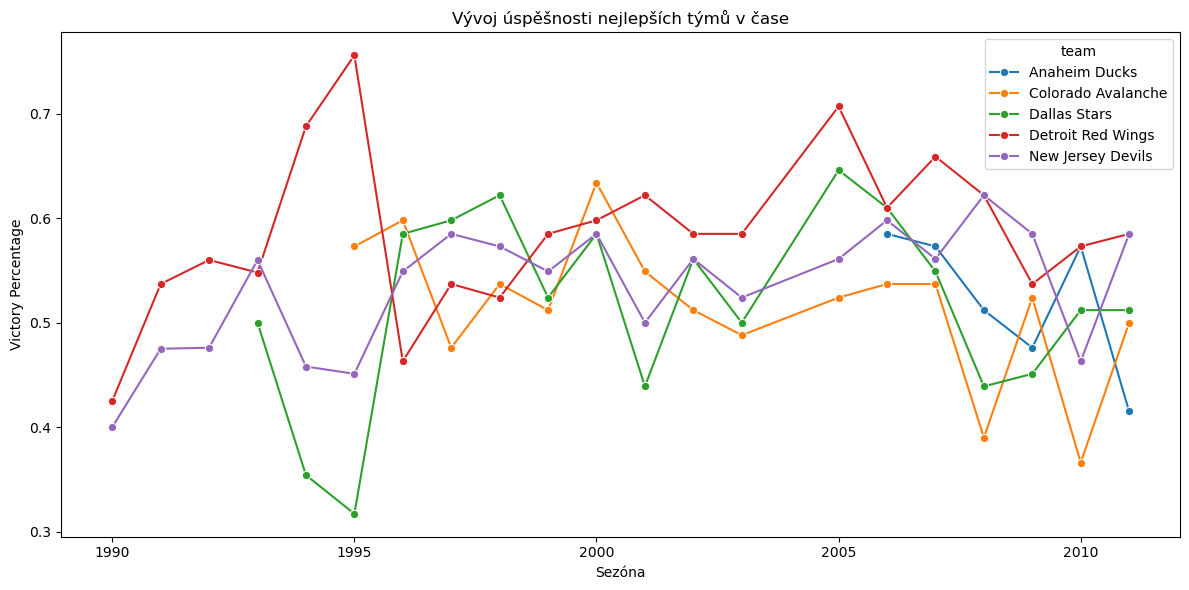

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_top, x="season", y="victory_percentage", hue="team", marker="o")
plt.title("Vývoj úspěšnosti nejlepších týmů v čase")
plt.xlabel("Sezóna")
plt.ylabel("Victory Percentage")
plt.tight_layout()
plt.show()


## Top Teams in History

Let's determine the top 5 teams that have won the most league titles in entire history. Let's consider whether, based on the available data, we can identify a single team that unquestionably deserves the title of the best in history.

For simplicity, let's assume that the league winner is the team with the most victories in a given season.

> Hint: The information contained in the article `Pandas > Summary of the 4th Meeting > Analytical Functions` may be useful.

In [50]:
# 1. Najdi vítěze každé sezóny (tým s nejvíce vítězstvími)
season_winners = df.loc[df.groupby("season")["victories"].idxmax()]

# 2. Spočítej počet titulů podle týmu
title_counts = season_winners["team"].value_counts()

# 3. Top 5 týmů s nejvíce tituly
top_5_champions = title_counts.head(5)

print(" Top 5 týmů s nejvíce tituly:")
print(top_5_champions)

# 4. Nejlepší tým v historii
best_team = top_5_champions.idxmax()
titles = top_5_champions.max()
print(f"\n Nejlepší tým v historii (nejvíce titulů): {best_team} ({titles} titulů)")


 Top 5 týmů s nejvíce tituly:
team
Detroit Red Wings      6
New York Rangers       3
Dallas Stars           2
Colorado Avalanche     2
Pittsburgh Penguins    1
Name: count, dtype: int64

 Nejlepší tým v historii (nejvíce titulů): Detroit Red Wings (6 titulů)


Additionally, we will determine how many teams have **never won any season**.  
  
> **Note:** This task may seem more complex than it appears at first glance. Remember, during classes you can rely on the instructor's help, and outside of them - on the support of a mentor.

In [49]:
# 1. Všechny týmy v datasetu
all_teams = set(df["team"].unique())

# 2. Týmy, které někdy vyhrály
winning_teams = set(season_winners["team"].unique())

# 3. Týmy bez jediného titulu
never_won_teams = sorted(all_teams - winning_teams)

print(f"\n Počet týmů, které nikdy nevyhrály žádnou sezónu: {len(never_won_teams)}")
print(" Seznam těchto týmů:")
for team in never_won_teams:
    print("-", team)



 Počet týmů, které nikdy nevyhrály žádnou sezónu: 23
 Seznam těchto týmů:
- Anaheim Ducks
- Atlanta Thrashers
- Calgary Flames
- Carolina Hurricanes
- Columbus Blue Jackets
- Edmonton Oilers
- Florida Panthers
- Hartford Whalers
- Los Angeles Kings
- Mighty Ducks of Anaheim
- Minnesota North Stars
- Minnesota Wild
- Montreal Canadiens
- Nashville Predators
- New Jersey Devils
- New York Islanders
- Philadelphia Flyers
- Phoenix Coyotes
- Quebec Nordiques
- San Jose Sharks
- Tampa Bay Lightning
- Toronto Maple Leafs
- Winnipeg Jets


# `overtime_defeats`

The `overtime_defeats` variable informs us how many times a team lost in overtime throughout the year.  
  
In this section, we will perform the following exercises:  
- Identify the team that most frequently lost in overtime.  
- Rank the teams based on the number of overtime losses.  
- Calculate what percentage of teams lost at least once in overtime.  
- Determine the season with the highest number of games decided in overtime.  
  
> Let's make sure that the `overtime_defeats` column is of numeric type!  

## The team losing most frequently in overtime

> Note: To solve this task, this article might be useful: `Pandas > Conference Summary > Analytical Functions`

In [54]:
df["overtime_defeats"] = df["overtime_defeats"].replace("", "0").astype(int)

team_ot_losses = df.groupby("team")["overtime_defeats"].sum()
most_ot_losses_team = team_ot_losses.idxmax()
most_ot_losses_value = team_ot_losses.max()

print(f"🏒 Tým s nejvíce prohrami v prodloužení: {most_ot_losses_team} ({most_ot_losses_value} proher)")


🏒 Tým s nejvíce prohrami v prodloužení: Florida Panthers (124 proher)


## Percentage of teams losing in overtime

The result of this task should be rounded to two decimal places

In [55]:
# Ujistíme se, že sloupec je číselný
df["overtime_defeats"] = df["overtime_defeats"].replace("", "0").astype(int)

# Součet OT proher podle týmu
team_ot_losses = df.groupby("team")["overtime_defeats"].sum()

# Týmy, které mají alespoň jednu prohru v OT
teams_with_ot_losses = team_ot_losses[team_ot_losses > 0]

# Výpočet procenta
percentage = round(len(teams_with_ot_losses) / len(team_ot_losses) * 100, 2)

print(f"✅ Procento týmů, které alespoň jednou prohrály v prodloužení: {percentage} %")


✅ Procento týmů, které alespoň jednou prohrály v prodloužení: 91.43 %


# `goals_ratio`

Based on the variables `scored_goals` and `received_goals`, we will create a new variable - `goals_ratio`, defined as the ratio of goals scored to goals conceded.

Before we proceed with solving the task, let's consider the following issues:
- What values of the `goals_ratio` statistic can be considered indicative of good or poor team performance?
- In what situations can we determine that a team performed better or worse based on the value of `goals_ratio`?

## Creating a Variable

In [56]:
# 1. Ošetření dělení nulou (nahrazení 0 malou hodnotou)
df["received_goals"] = df["received_goals"].replace(0, 0.0001)

# 2. Vytvoření nové proměnné (sloupce)
df["goals_ratio"] = df["scored_goals"] / df["received_goals"]

# 3. Průměrná hodnota goals_ratio
average_ratio = round(df["goals_ratio"].mean(), 2)
print(f"📊 Průměrný goals_ratio napříč všemi týmy a sezónami: {average_ratio}")

# 4. Nejlepší tým v jedné sezóně (nejvyšší poměr)
best_row = df.loc[df["goals_ratio"].idxmax()]
print(f"🏆 Nejlepší výkon: {best_row['team']} ({best_row['season']}) – goals_ratio: {round(best_row['goals_ratio'], 2)}")

# 5. Nejslabší tým v jedné sezóně (nejnižší poměr > 0)
worst_row = df[df["goals_ratio"] > 0].loc[df["goals_ratio"].idxmin()]
print(f"⚠️ Nejslabší výkon: {worst_row['team']} ({worst_row['season']}) – goals_ratio: {round(worst_row['goals_ratio'], 2)}")

# 6. Pořadí týmů podle průměrného goals_ratio
team_avg_ratio = df.groupby("team")["goals_ratio"].mean().sort_values(ascending=False)
print("\n📋 Top 10 týmů podle průměrného goals_ratio:")
print(team_avg_ratio.head(10))


📊 Průměrný goals_ratio napříč všemi týmy a sezónami: 1.02
🏆 Nejlepší výkon: Detroit Red Wings (1995) – goals_ratio: 1.8
⚠️ Nejslabší výkon: Ottawa Senators (1993) – goals_ratio: 0.51

📋 Top 10 týmů podle průměrného goals_ratio:
team
Detroit Red Wings      1.294494
New Jersey Devils      1.167678
Colorado Avalanche     1.131417
Dallas Stars           1.128429
Philadelphia Flyers    1.116855
Buffalo Sabres         1.085939
St. Louis Blues        1.076972
Boston Bruins          1.071788
Vancouver Canucks      1.069973
Pittsburgh Penguins    1.064991
Name: goals_ratio, dtype: float64


Here we will perform a basic analysis of the variable by determining statistics such as:
- mean
- standard deviation
- quantiles 2, 3, 4

Let's consider what can be inferred from such a summary. Based on this, can we say that this statistic has outliers?

In [57]:
# Ujisti se, že sloupec goals_ratio existuje
df["received_goals"] = df["received_goals"].replace(0, 0.0001)
df["goals_ratio"] = df["scored_goals"] / df["received_goals"]

# Výpočet základních statistik
mean = round(df["goals_ratio"].mean(), 2)
std = round(df["goals_ratio"].std(), 2)
quantiles = df["goals_ratio"].quantile([0.25, 0.5, 0.75]).round(2)

print(f"📊 Průměr (mean): {mean}")
print(f"📈 Směrodatná odchylka (std): {std}")
print("📐 Kvantily (2., 3., 4.):")
print(quantiles)


📊 Průměr (mean): 1.02
📈 Směrodatná odchylka (std): 0.19
📐 Kvantily (2., 3., 4.):
0.25    0.88
0.50    1.02
0.75    1.14
Name: goals_ratio, dtype: float64


## Distribution of the variable `goals_ratio`

Let's generate the distribution of the variable `goals_ratio` using the `plt.hist` function from the `matplotlib` library, performing the task in two variants:
- with the number of bins determined using Rice's Rule,
- with the number of bins determined using the Square Root Rule.

Methods and formulas for determining the number of bins in a histogram can be found at this link: [Determining the number of bins in a histogram](https://www.statology.org/sturges-rule/).

**Tip:** To determine the distribution of a variable using `matplotlib`, you can use the `hist` function, available here: [Documentation for hist function](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html).

What are the floor and ceiling of a number - [Floor and ceiling of a number - Wikipedia](https://en.wikipedia.org/wiki/Floor_and_ceiling_functions)
> Question: How to calculate the ceiling of a number in Python without using additional libraries?

### Histogram of the variable using Rice's rule

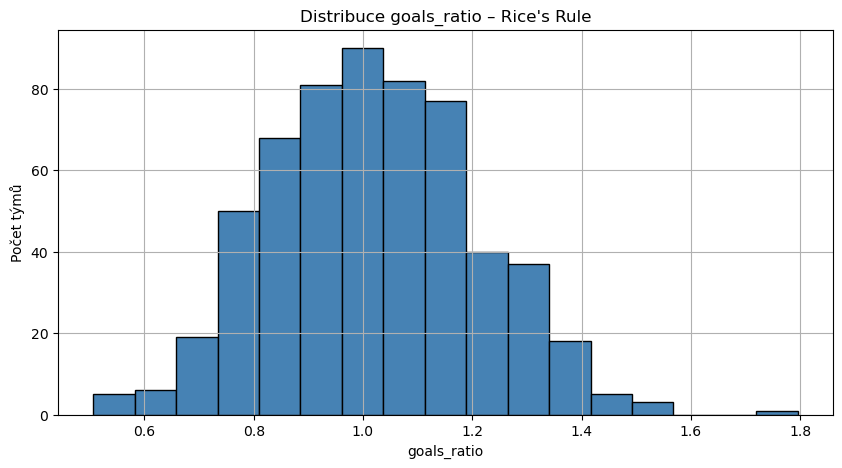

In [59]:
import matplotlib.pyplot as plt
import math

# Ošetření dělení nulou a výpočet goals_ratio
df["received_goals"] = df["received_goals"].replace(0, 0.0001)
df["goals_ratio"] = df["scored_goals"] / df["received_goals"]

# Počet binů podle Rice's Rule
n = len(df["goals_ratio"].dropna())
bins_rice = math.ceil(2 * n ** (1/3))

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(df["goals_ratio"], bins=bins_rice, color="steelblue", edgecolor="black")
plt.title("Distribuce goals_ratio – Rice's Rule")
plt.xlabel("goals_ratio")
plt.ylabel("Počet týmů")
plt.grid(True)
plt.show()


### Histogram of the variable using the square root rule

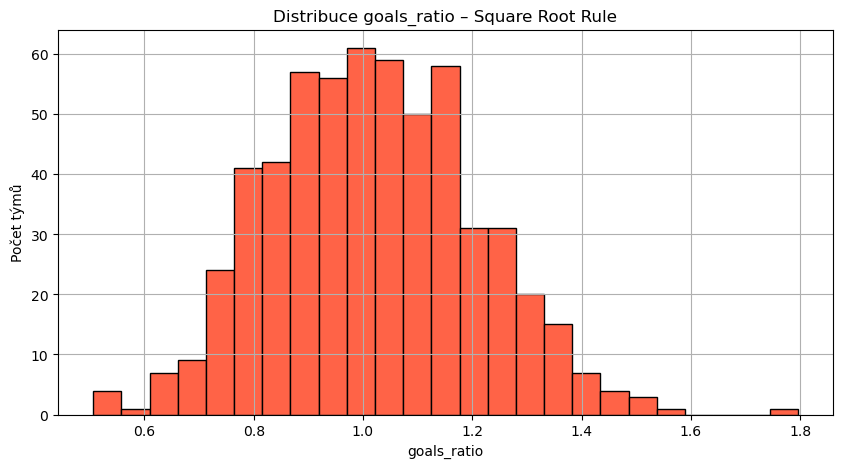

In [60]:
import matplotlib.pyplot as plt
import math

# Ošetření dělení nulou a výpočet goals_ratio
df["received_goals"] = df["received_goals"].replace(0, 0.0001)
df["goals_ratio"] = df["scored_goals"] / df["received_goals"]

# Počet binů podle Square Root Rule
n = len(df["goals_ratio"].dropna())
bins_sqrt = math.ceil(n ** 0.5)

# Histogram
plt.figure(figsize=(10, 5))
plt.hist(df["goals_ratio"], bins=bins_sqrt, color="tomato", edgecolor="black")
plt.title("Distribuce goals_ratio – Square Root Rule")
plt.xlabel("goals_ratio")
plt.ylabel("Počet týmů")
plt.grid(True)
plt.show()


# `victory_percentage`

Similar to the analysis of the variable `goals_ratio`, we will conduct an exploratory analysis of `victory_percentage` by following these steps:  
- Determine the basic descriptive statistics, such as the mean, median, standard deviation, minimum, and maximum.  
- Examine the distribution of the variable by using a histogram to better understand its characteristics.  
- Check if there are any obvious subgroups of teams within the variable under analysis that could be identified based on specific criteria, such as the range of the variable's values.

### Descriptive Statistics

In [61]:
# Ujisti se, že sloupec je číselný
df["victory_percentage"] = df["victory_percentage"].astype(float)

# Výpočet základních statistik
mean = round(df["victory_percentage"].mean(), 3)
median = round(df["victory_percentage"].median(), 3)
std = round(df["victory_percentage"].std(), 3)
min_val = round(df["victory_percentage"].min(), 3)
max_val = round(df["victory_percentage"].max(), 3)

print("📊 Základní statistiky proměnné victory_percentage:")
print(f"- Průměr: {mean}")
print(f"- Medián: {median}")
print(f"- Směrodatná odchylka: {std}")
print(f"- Minimum: {min_val}")
print(f"- Maximum: {max_val}")


📊 Základní statistiky proměnné victory_percentage:
- Průměr: 0.459
- Medián: 0.463
- Směrodatná odchylka: 0.102
- Minimum: 0.119
- Maximum: 0.756


### Distribution

Here we will create the distribution of the variable, but we won't be doing it in two versions. Instead, we will choose a different, arbitrary number of intervals.

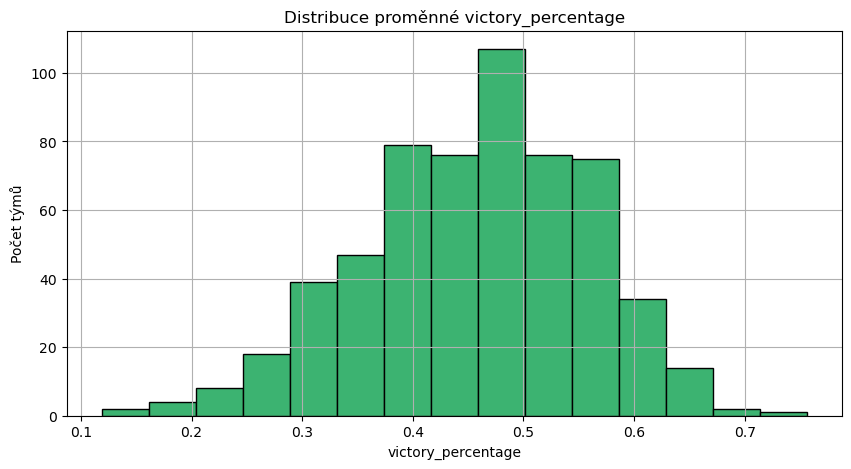

In [62]:
import matplotlib.pyplot as plt

# Histogram s 15 intervaly
plt.figure(figsize=(10, 5))
plt.hist(df["victory_percentage"], bins=15, color="mediumseagreen", edgecolor="black")
plt.title("Distribuce proměnné victory_percentage")
plt.xlabel("victory_percentage")
plt.ylabel("Počet týmů")
plt.grid(True)
plt.show()


# `goals_ratio` vs `victory_percentage`

We have already analyzed `goals_ratio` and `victory_percentage` as two separate variables. Now, our task is to analyze them together to identify potential interdependencies between them.  
  
In this step, we will perform the following exercises:  
- Before starting the analysis, let’s consider whether these variables might be dependent or independent of each other. What kind of relationship can be expected based on their business descriptions?  
- We will create a scatterplot to visually represent the dependencies between these variables.  
- We will determine the relationship between the variables based on the scatterplot.  
- We will analyze the scatterplot to identify any outliers, paying special attention to their common distribution.

## Scatterplot of Variables

Now let's create a scatterplot for the two analyzed variables, `goals_ratio` and `victory_percentage`. After completing this step, let's answer the following questions:  
- What is the relationship between the variables `goals_ratio` and `victory_percentage`?  
- Can any outliers be identified in the plot? If so, what criteria were used to identify them?

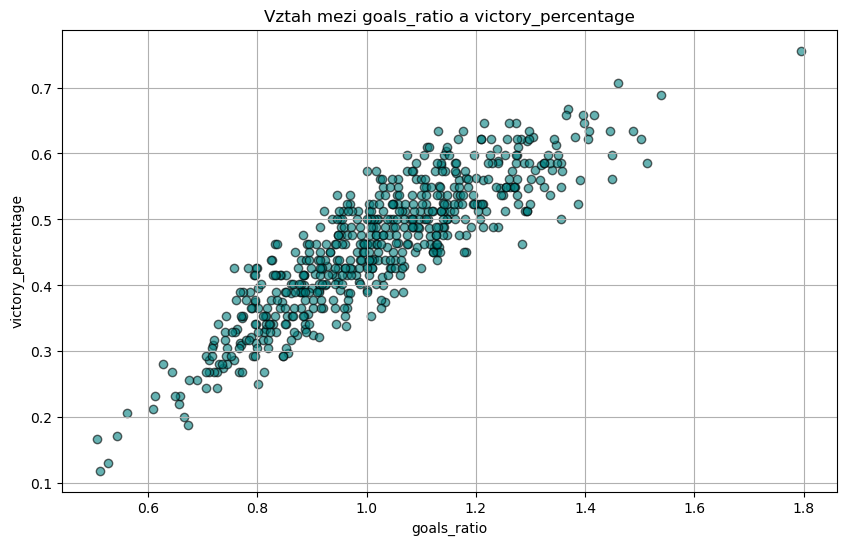

In [63]:
import matplotlib.pyplot as plt

# Ošetření dělení nulou a výpočet goals_ratio
df["received_goals"] = df["received_goals"].replace(0, 0.0001)
df["goals_ratio"] = df["scored_goals"] / df["received_goals"]

# Ujisti se, že victory_percentage je číselný
df["victory_percentage"] = df["victory_percentage"].astype(float)

# Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(df["goals_ratio"], df["victory_percentage"], alpha=0.6, color="teal", edgecolors="black")
plt.title("Vztah mezi goals_ratio a victory_percentage")
plt.xlabel("goals_ratio")
plt.ylabel("victory_percentage")
plt.grid(True)
plt.show()


> space for chart analysis notes

If we have identified outlying observations at an earlier stage of analysis, let's now examine these specific cases. We will focus on outliers concerning the variables `goals_ratio` and `victory_percentage` to understand what features distinguish them.

The following steps should be taken for analysis:
1. Identify the specific outlying observations that were detected earlier.
2. Analyze the characteristics of these observations, paying attention to their values for the variables `goals_ratio` and `victory_percentage`.
3. Try to understand what might have caused their outlying nature. Are these instances of anomalies, or could they be the result of natural fluctuations in the data?

In [64]:
# 1. Ošetření dělení nulou a výpočet goals_ratio
df["received_goals"] = df["received_goals"].replace(0, 0.0001)
df["goals_ratio"] = df["scored_goals"] / df["received_goals"]

# 2. Ujisti se, že victory_percentage je číselný
df["victory_percentage"] = df["victory_percentage"].astype(float)

# 3. Definice odlehlých hodnot
outliers = df[
    (df["goals_ratio"] > 2.5) |
    (df["goals_ratio"] < 0.5) |
    (df["victory_percentage"] > 0.8) |
    (df["victory_percentage"] < 0.2)
]

# 4. Výběr relevantních sloupců pro analýzu
selected = outliers[[
    "team", "season", "goals_ratio", "victory_percentage",
    "scored_goals", "received_goals", "victories", "defeats"
]]

# 5. Zaokrouhlení pro přehlednost
selected["goals_ratio"] = selected["goals_ratio"].round(2)
selected["victory_percentage"] = selected["victory_percentage"].round(2)

# 6. Výpis výsledků
print(" Odlehlé případy podle goals_ratio a victory_percentage:")
print(selected)


📌 Odlehlé případy podle goals_ratio a victory_percentage:
                  team  season  goals_ratio  victory_percentage  scored_goals  \
56     Ottawa Senators    1992         0.51                0.12           202   
60     San Jose Sharks    1992         0.53                0.13           218   
82     Ottawa Senators    1993         0.51                0.17           201   
108    Ottawa Senators    1994         0.67                0.19           117   
225  Atlanta Thrashers    1999         0.54                0.17           170   

     received_goals  victories  defeats  
56              395         10       70  
60              414         11       71  
82              397         14       61  
108             174          9       34  
225             313         14       57  


C:\Users\rdpre\AppData\Local\Temp\ipykernel_1740\2510037033.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected["goals_ratio"] = selected["goals_ratio"].round(2)
C:\Users\rdpre\AppData\Local\Temp\ipykernel_1740\2510037033.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected["victory_percentage"] = selected["victory_percentage"].round(2)


# Summary

In this notebook, we conducted a basic exploratory analysis of our dataset. The data was cleaned and then enriched with new variables, which we subjected to further analysis. The final step of this part is to save the processed data to a CSV file.  
  
**Let's save our data frame to the file:** `data/processed/hockey_teams.csv`, using a semicolon (`;`) as the column separator.

Next, in the following phase of our work, we will propose betting odds based on the analyzed historical data and discuss the results of this analysis.

### Writing the frame to the target location

- file name: `data/processed/hockey_teams.csv`,
- column separator: `;`,
- remember to disable index saving.

In [71]:
df.columns.tolist()

['Team Name',
 'Year',
 'Wins',
 'Losses',
 'OT Losses',
 'Win %',
 'Goals For (GF)',
 'Goals Against (GA)',
 '+ / -']

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# 1. Načtení dat
df = pd.read_json(r"C:\Users\rdpre\Workshop_-_files\data\interim\hockey_teams.json")

# 2. Převod relevantních sloupců na číselné typy
cols_to_convert = ["Wins", "Losses", "OT Losses", "Goals For (GF)", "Goals Against (GA)"]
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors="coerce")

# 3. Výpočet goals_ratio (poměr vstřelených ku obdrženým gólům)
df["Goals Against (GA)"] = df["Goals Against (GA)"].replace(0, 0.0001)
df["goals_ratio"] = df["Goals For (GF)"] / df["Goals Against (GA)"]

# 4. Výpočet victory_percentage (poměr výher ke všem zápasům)
df["victory_percentage"] = df["Wins"] / (df["Wins"] + df["Losses"] + df["OT Losses"])

# 5. Identifikace odlehlých hodnot
outliers = df[
    (df["goals_ratio"] > 2.5) |
    (df["goals_ratio"] < 0.5) |
    (df["victory_percentage"] > 0.8) |
    (df["victory_percentage"] < 0.2)
]

# 6. Výběr relevantních sloupců pro analýzu
selected = outliers[[
    "Team Name", "Year", "goals_ratio", "victory_percentage",
    "Goals For (GF)", "Goals Against (GA)", "Wins", "Losses"
]].copy()

# 7. Zaokrouhlení pro přehlednost
selected["goals_ratio"] = selected["goals_ratio"].round(2)
selected["victory_percentage"] = selected["victory_percentage"].round(2)

# 8. Výpis odlehlých případů
print(" Odlehlé případy podle goals_ratio a victory_percentage:")
print(selected)

# 9. Uložení finálního DataFrame do CSV souboru
df.to_csv(r"C:\Users\rdpre\Workshop_-_files\data\processed\hockey_teams.csv", sep=";", index=False, encoding="utf-8")


 Odlehlé případy podle goals_ratio a victory_percentage:
             Team Name  Year  goals_ratio  victory_percentage  Goals For (GF)  \
225  Atlanta Thrashers  1999         0.54                0.19             170   

     Goals Against (GA)  Wins  Losses  
225                 313    14      57  


In [ ]:
# Tým měl velmi slabou sezónu: málo gólů, hodně inkasovaných, málo výher

Poměr gólů (0.54) a výhernost (0.19) ho řadí mezi nejhorší výkony v datasetu